# Paramétrage de l'environnement de travail et import des packages

In [66]:
import sys
from pathlib import Path

In [122]:
ROOT = Path.cwd().parents[0]

RAW_DATA = ROOT / "01_data" / "01_raw"
PROCESSED_DATA = ROOT / "01_data" / "02_processed"
MODEL_DATA = ROOT / "04_model"

%load_ext autoreload
%autoreload 2
sys.path.append(str(ROOT / "03_fonctions"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import pandas as pd
import numpy as np
from fonctions_perso.data_manipulation import multi_astype

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector

from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform
from sklearn.calibration import CalibratedClassifierCV

from fonctions_perso.machine_learning import IsolationForestCustom
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import seaborn as sns
import matplotlib.pyplot as plt
from fonctions_perso.machine_learning import ThresholdCostOptimizer, BinaryMetricsSimple, graphique_courbe_pr, graphique_courbe_calibration

from sklearn import set_config
set_config(transform_output="pandas")

import joblib


# La base de données

In [69]:
data_fraud = pd.read_parquet(PROCESSED_DATA / "data_fraud_eda_processed.parquet").reset_index(drop = True)

In [70]:
multi_astype(
    data_fraud,
    ["type_magasin","etat_client","heure_transaction"],
    "string"
)

type_magasin: object → string
etat_client: object → string
heure_transaction: int32 → string

Succès: 3/3


**Informations globales**

In [71]:
data_fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 19 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   nom_magasin                object 
 1   type_magasin               string 
 2   montant_transaction        float64
 3   ville_client               object 
 4   etat_client                string 
 5   latitude_domicile_client   float64
 6   longitude_domicile_client  float64
 7   population_ville_client    int64  
 8   profession_client          object 
 9   numero_transaction         object 
 10  latitude_magasin           float64
 11  longitude_magasin          float64
 12  target                     int64  
 13  annee_transaction          int32  
 14  mois_transaction           object 
 15  jour_transaction           object 
 16  heure_transaction          string 
 17  distance_domicile_magasin  float64
 18  age_client                 int32  
dtypes: float64(6), int32(2), int64(2), object(

**Statistiques descriptives**

In [72]:
data_fraud.describe()

,montant_transaction,latitude_domicile_client,longitude_domicile_client,population_ville_client,latitude_magasin,longitude_magasin,target,annee_transaction,distance_domicile_magasin,age_client
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,7.006357e+01,3.853931e+01,-9.022783e+01,8.864367e+04,3.853898e+01,-9.022794e+01,5.210015e-03,2.019501e+03,7.611183e+01,4.621138e+01
std,1.592540e+02,5.071470e+00,1.374789e+01,3.014876e+05,5.105604e+00,1.375969e+01,7.199217e-02,4.999996e-01,2.911701e+01,1.739545e+01
min,1.000000e+00,2.002710e+01,-1.656723e+02,2.300000e+01,1.902742e+01,-1.666716e+02,0.000000e+00,2.019000e+03,2.225455e-02,1.400000e+01
25%,9.640000e+00,3.466890e+01,-9.679800e+01,7.410000e+02,3.474012e+01,-9.689944e+01,0.000000e+00,2.019000e+03,5.532016e+01,3.300000e+01
50%,4.745000e+01,3.935430e+01,-8.747690e+01,2.443000e+03,3.936890e+01,-8.744069e+01,0.000000e+00,2.020000e+03,7.821649e+01,4.400000e+01
75%,8.310000e+01,4.194040e+01,-8.015800e+01,2.032800e+04,4.195626e+01,-8.024511e+01,0.000000e+00,2.020000e+03,9.850960e+01,5.700000e+01
max,2.894890e+04,6.669330e+01,-6.795030e+01,2.906700e+06,6.751027e+01,-6.695090e+01,1.000000e+00,2.020000e+03,1.521174e+02,9.600000e+01


**Aperçu rapide des données**

In [73]:
data_fraud.head()

,nom_magasin,type_magasin,montant_transaction,ville_client,etat_client,latitude_domicile_client,longitude_domicile_client,population_ville_client,profession_client,numero_transaction,latitude_magasin,longitude_magasin,target,annee_transaction,mois_transaction,jour_transaction,heure_transaction,distance_domicile_magasin,age_client
0,Kirlin and Sons,personal_care,2.86,Columbia,SC,33.9659,-80.9355,333497,Mechanical engineer,2da90c7d74bd46a0caf3777415b3ebd3,33.986391,-81.200714,0,2020,June,Sunday,12,24.561496,52
1,Sporer-Keebler,personal_care,29.84,Altonah,UT,40.3207,-110.4360,302,"Sales professional, IT",324cc204407e99f51b0d6ca0055005e7,39.450498,-109.960431,0,2020,June,Sunday,12,104.925237,30
2,"Swaniawski, Nitzsche and Welch",health_fitness,41.28,Bellmore,NY,40.6729,-73.5365,34496,"Librarian, public",c81755dbbbea9d5c77f094348a7579be,40.495810,-74.196111,0,2020,June,Sunday,12,59.080159,50
3,Haley Group,misc_pos,60.05,Titusville,FL,28.5697,-80.8191,54767,Set designer,2159175b9efe66dc301f149d3d5abf8c,28.812398,-80.883061,0,2020,June,Sunday,12,27.698606,33
4,Johnston-Casper,travel,3.19,Falmouth,MI,44.2529,-85.0170,1126,Furniture designer,57ff021bd3f328f8738bb535c302a31b,44.959148,-85.884734,0,2020,June,Sunday,12,104.335250,65


# Machine Learning

**Construction de l'échantillon train | validation | test**

In [ ]:
periode_validation = ["January","February","March","April","May","June","July","August","September"]

data_fraud_2020_validation = data_fraud[(data_fraud["annee_transaction"]==2020) & (data_fraud["mois_transaction"].isin(periode_validation))]
data_fraud_2020_test = data_fraud[(data_fraud["annee_transaction"]==2020) & (~data_fraud["mois_transaction"].isin(periode_validation))]


In [104]:
# Taux de transactions frauduleuses sur l'échantillon train
data_fraud[data_fraud["annee_transaction"]==2019]["target"].mean()

0.005644158512191166

In [105]:
# Taux de transactions frauduleuses sur l'échantillon de validation pour la recherche du seuil
data_fraud_2020_validation["target"].mean()

0.005410024101309086

In [106]:
# Taux de transactions frauduleuses sur l'échantillon test
data_fraud_2020_test["target"].mean()

0.003324796373982758

In [107]:
variables_a_retirer = ["target","nom_magasin","ville_client","profession_client","numero_transaction",
                       "annee_transaction","latitude_domicile_client","longitude_domicile_client",
                       "latitude_magasin","longitude_magasin","mois_transaction","jour_transaction"]


x_train = data_fraud[data_fraud["annee_transaction"]==2019].drop(variables_a_retirer, axis=1)
y_train = data_fraud[data_fraud["annee_transaction"]==2019]["target"]

x_validation = data_fraud_2020_validation.drop(variables_a_retirer, axis=1)
y_validation = data_fraud_2020_validation["target"]

x_test = data_fraud_2020_test.drop(variables_a_retirer, axis=1)
y_test = data_fraud_2020_test["target"]

**Création de la pipeline**

In [48]:
# Preprocessing
    # -- Encodage des variables catégorielles 
var_cat_pipe = Pipeline([
    ("one_hot_encoder", OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore'))
])

    # -- Isolation Forest sur les données et création de la variable "if_score"
all_var_pipe = Pipeline([
    ("isolation_forest", IsolationForestCustom(
        n_estimators=100,        
        max_samples="auto",      
        contamination="auto",    
        max_features=1.0,        
        bootstrap=False,         
        n_jobs=-1,               
        random_state=1,         
        verbose=0,               
        warm_start=False         
    ))
])


# XGBoost (Objectif : Stabilité)
    # -- Modèle de base
xgb = XGBClassifier(
    scale_pos_weight=200, # 0.995/0.005
    random_state=1,
    n_jobs=-1
)

    # -- Préparation des hyperparamètres à tuner
hyperparametres = {
    "model__n_estimators": randint(50, 200),
    "model__max_depth": randint(3, 6),
    
        # --- Apprentissage lent (0.01 - 0.05)
    "model__learning_rate": loguniform(0.01, 0.05),
    
        # --- Bagging et Feature sampling forts
    "model__subsample": uniform(0.5, 0.3),        
    "model__colsample_bytree": uniform(0.5, 0.3), 
    
        # --- Régularisation forte sur les feuilles
    "model__min_child_weight": randint(5, 10),
    
        # --- Réduction de perte minimale pour splitter
    "model__gamma": loguniform(0.01, 0.5), 
    
        # --- Régularisation L1 et L2 (Forte)
    "model__reg_alpha": loguniform(0.1, 1.0),
    "model__reg_lambda": loguniform(1.0, 10.0)
}

In [49]:
# Assemblage 
preprocessing_1 = ColumnTransformer([
    ("one_hot_encoding", var_cat_pipe, make_column_selector(dtype_exclude=np.number))
], remainder="passthrough")

pipeline_complete = Pipeline([
    ("ohe", preprocessing_1),
    ("isolation_forest", all_var_pipe),
    ("model", xgb)
])

In [50]:
# Tuning des hyperparamètres
recherche = RandomizedSearchCV(
    estimator = pipeline_complete,
    param_distributions = hyperparametres,
    n_iter = 6,
    scoring = "neg_brier_score",
    cv = 3,  
    return_train_score = True,
    refit = True,
    random_state = 1,
    n_jobs = -1,
    error_score = "raise",
)

_ = recherche.fit(x_train, y_train)
modele = recherche.best_estimator_

In [51]:
# Calibration des probabilités
model_propre = CalibratedClassifierCV(
    estimator = modele,  
    method = 'isotonic',       
    cv = 5                    
)

_ = model_propre.fit(x_train, y_train)

**Sauvegarde des modèles**

In [123]:
# XGBoost non calibré
joblib.dump(modele, MODEL_DATA / "fraud_detection_xgb_pas_calibre.joblib")  

# XGBoost calibré
joblib.dump(model_propre, MODEL_DATA / "fraud_detection_model_xgboost.joblib") 

['c:\\Users\\user\\Desktop\\data_science_documents\\data_science_projets_perso\\projet_fraud_detection\\fraud-detection\\04_model\\fraud_detection_model_xgboost.joblib']

In [124]:
# modele_propre = joblib.load(MODEL_DATA / "fraud_detection_model_xgboost.joblib")

**Recherche du seuil de probabilité optimal à partir de l'échantillon 'validation'**

In [110]:
# Entrainement (Echantillon validation)
y_validation_proba = model_propre.predict_proba(x_validation)[:,1]

<Axes: title={'center': 'Répartition des probabilités (Echantillon validation)'}, xlabel='Probabilités', ylabel='Nombre'>

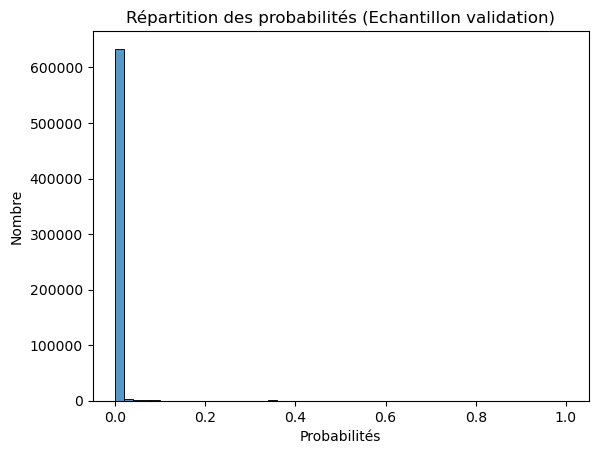

In [111]:
# Répartition des probabilités (Echantillon validation)
df_y_validation_proba = pd.DataFrame(y_validation_proba)
df_y_validation_proba = df_y_validation_proba.rename(columns={0:"proba"})

plt.title("Répartition des probabilités (Echantillon validation)")
plt.xlabel("Probabilités")
plt.ylabel("Nombre")

sns.histplot(
    df_y_validation_proba,
    x="proba",
    bins=50
)

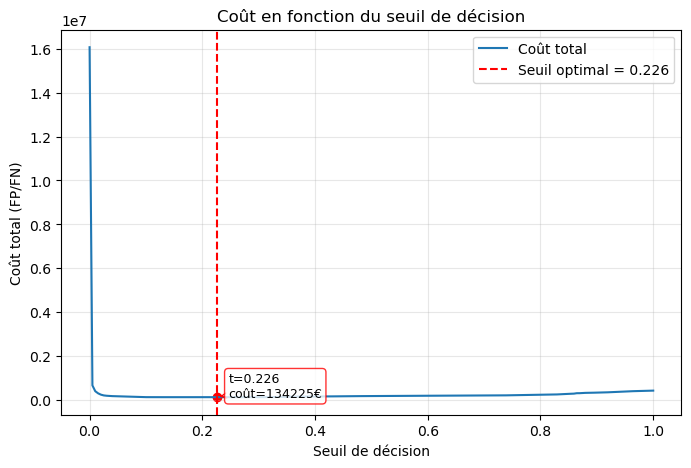

Meilleur seuil : 0.226 | Coût minimal : 134225.00€


In [112]:
# Recherche du seuil permettant de minimiser les couts à partir de l'échantillon "validation"
cost_optimizer = ThresholdCostOptimizer(cost_fp=25, cost_fn=125, n_thresholds=200)

cost_optimizer.fit(y_validation, y_validation_proba)

cost_optimizer.plot_cost_curve()

**Entrainement du modèle sur l'échantillon 'train' et 'test'**

In [113]:
# Train
train_proba = model_propre.predict_proba(x_train)[:,1]
train_pred = (train_proba >= cost_optimizer.get_best_threshold()).astype(int)

# Test
test_proba = model_propre.predict_proba(x_test)[:,1]
test_pred = (test_proba >= cost_optimizer.get_best_threshold()).astype(int)

**Sauvegarde des données test**

In [125]:
joblib.dump(x_test, PROCESSED_DATA / "x_test_for_shap.joblib")

joblib.dump(y_test, PROCESSED_DATA / "y_test_for_shap.joblib")

['c:\\Users\\user\\Desktop\\data_science_documents\\data_science_projets_perso\\projet_fraud_detection\\fraud-detection\\01_data\\02_processed\\y_test_for_shap.joblib']

# Analyse des performances du modèle

In [116]:
performances_modele = BinaryMetricsSimple(
    y_test, test_pred, test_proba
)

**Métriques**

In [117]:
performances_modele.get_metrics_df() # Métriques principales

,Metrique,Valeur
0,accuracy,0.9967
1,precision,0.4997
2,recall,0.7874
3,f1,0.6114
4,mcc,0.6257
5,roc_auc,0.9917
6,brier_score,0.0016
7,average_precision,0.7182


In [118]:
performances_modele.print_confusion_matrix() # Matrice de confusion

MATRICE DE CONFUSION
                      Prédit Négatif | Prédit Positif
Réel Négatif              279847 |            738
Réel Positif                 199 |            737


**Courbe Précision-Rappel**

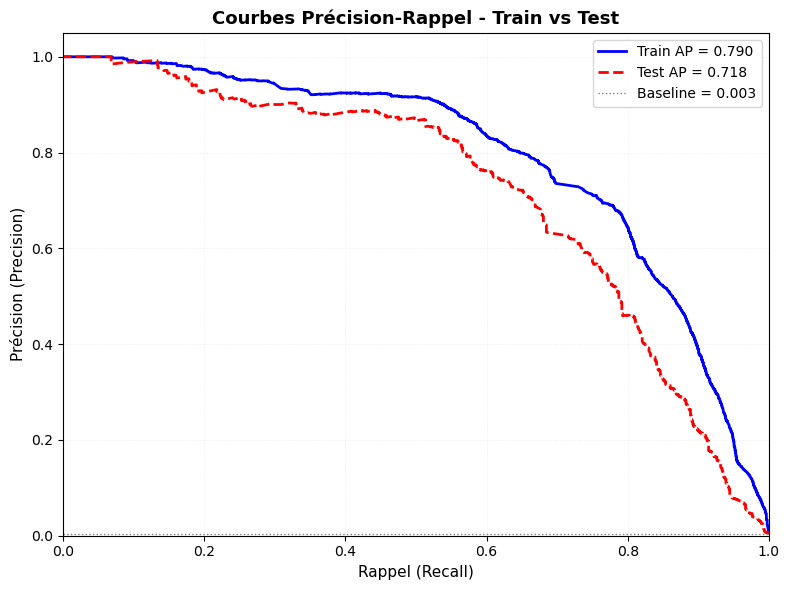


RÉSULTATS PRÉCISION-RAPPEL
AP Train     : 0.7895
AP Test      : 0.7182
Écart        : 0.0713
Baseline     : 0.0033
⚠️  Attention : écart élevé (possible overfitting)
Lift vs baseline : 216.01x


In [119]:
graphique_courbe_pr(
    y_train, train_proba,
    y_test, test_proba
)

**Courbe de calibration**

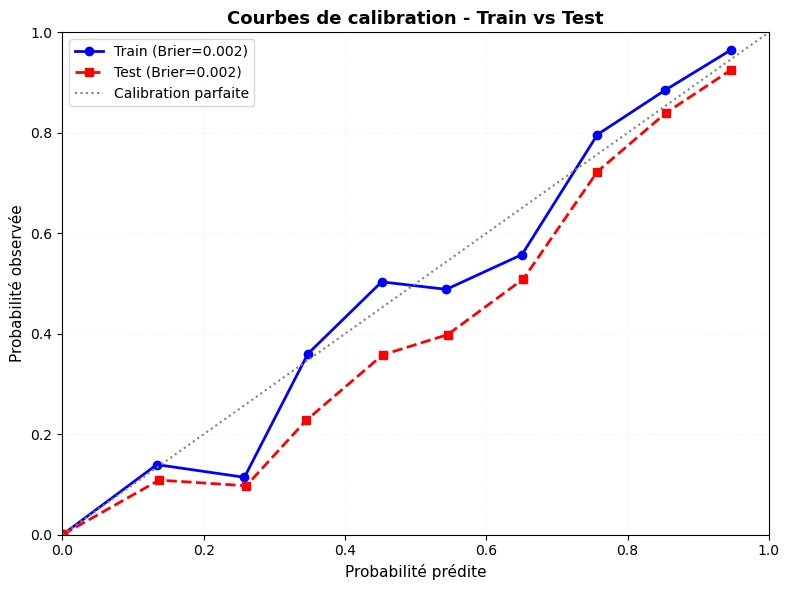


RÉSULTATS DE CALIBRATION
Brier Score Train : 0.0022
Brier Score Test  : 0.0016
Écart Brier       : 0.0006

ECE Train         : 0.0451
ECE Test          : 0.0765

---------------------------------------------
INTERPRÉTATION :
✓ Excellente calibration (Brier < 0.1)
⚠️  Erreur de calibration modérée (ECE < 0.1)


In [120]:
graphique_courbe_calibration(
    y_train, train_proba,
    y_test, test_proba
)

# Note explicative du Notebook


---

## 1. Stratégie de découpage temporel

Afin de se rapprocher d’une logique de détection en temps réel, le découpage retenu est strictement chronologique :

- **Train** : données 2019  
- **Validation (recherche du seuil)** : janvier 2020 - septembre 2020  
- **Test final** : octobre 2020 - décembre 2020  

Ce protocole simule un déploiement réel :  
le modèle est entraîné sur l’historique, le seuil est calibré sur les données les plus récentes disponibles, puis évalué sur une période ultérieure totalement hors échantillon.

---

## 2. Hypothèse économique

Le seuil de décision est optimisé selon la fonction de coût :

> Coût total = 25 × Nombre de faux positifs + 125 × Nombre de faux négatifs  

- Faux positif : **25 €**  
- Faux négatif : **125 €**  

La fraude non détectée est donc **5 fois plus coûteuse** qu’une fausse alerte.

---

## 3. Drift observé

Évolution du taux de fraude par période :

- **Train (2019)** : 0,056 %  
- **Validation (jan-sept 2020)** : 0,054 %  
- **Test (oct-déc 2020)** : 0,033 %  

Le taux de fraude diminue significativement sur la période de test.  

Le seuil optimisé sur la validation (régime ≈ 0,05 %) devient donc **relativement plus permissif** lorsqu’il est appliqué au test (régime ≈ 0,03 %), ce qui entraîne logiquement :

- Un **rappel élevé**  
- Une **baisse mécanique de la précision**

---

## 4. Résultats sur l’échantillon test (oct-déc 2020)

### 4.1 Seuil retenu

- **Seuil optimal** : 0,226  
- **Coût minimal observé sur validation** : 134 225 €  

### 4.2 Matrice de confusion (test)

- TP = 737  
- FN = 199  
- FP = 738  
- TN = 279 847  

- Fraudes réelles : 936  
- Alertes totales : 1 475  

### 4.3 Indicateurs de performance

- **Fraud Capture Rate (Recall)** : 78,7 %  
  - 737 fraudes détectées sur 936  
- **Fraud Loss Rate** : 21,3 %  
- **Précision** : 49,9 %  
  - 1 alerte sur 2 correspond à une fraude réelle  
- **Alert Rate** : 0,52 % des transactions envoyées en alerte  
- **False Positive Rate (FPR)** : 0,26 %  
- **Ratio FP / TP** : 1  
  - 1 faux positif pour 1 vrai positif  
- **ROC-AUC** : 0,9917  
- **Average Precision (test)** : 0,718  
- **Brier Score** : 0,0016  

---

## 5. Interprétation

### 5.1 Pouvoir discriminant

- L’AUC proche de **0,99** confirme une **excellente capacité de séparation** entre transactions frauduleuses et légitimes.  
- Il n’y a pas d’effondrement structurel des performances entre train et test.

### 5.2 Effet du drift de prévalence

La baisse du taux de fraude explique :

- La baisse de la **précision**  
- L’écart d’**Average Precision** entre train (0,790) et test (0,718)  

Cet écart est principalement lié au **changement de prévalence**, et non à un surapprentissage massif du modèle.

### 5.3 Calibration

Les courbes de calibration montrent :

- Une légère **surestimation** des probabilités en test (logique compte tenu de la baisse de prévalence)  
- Des **Brier scores très proches** entre train et test  

Cela indique une **cohérence probabiliste satisfaisante** et écarte l’hypothèse d’un overfit sévère.

---

## 6. Lecture économique

Le seuil 0,226 :

- **Privilégie le rappel**, conformément à la hiérarchie des coûts (FN plus chers que FP).  
- Dans un contexte où le taux de fraude passe de ≈ 0,05 % à ≈ 0,03 %, ce seuil n’est probablement plus l’optimum absolu sur la période test.  

Un arbitrage métier raisonnable consisterait à **ajuster légèrement le seuil à la hausse** afin :

- De **réduire les faux positifs**  
- D’**améliorer la précision**  
- Tout en maintenant un niveau de rappel acceptable  

Cela correspond à une logique réaliste de **recalibrage opérationnel**.

---

## 7. Conclusion

Dans son état actuel, le modèle :

- Discrimine efficacement les transactions (**AUC ≈ 0,99**)  
- Reste **bien calibré**  
- Maintient un **rappel élevé** (≈ 79 %)  
- Génère un **volume d’alertes limité** (0,52 % des transactions)  

Le compromis **rappel / précision** est cohérent avec la structure de coûts retenue.  

La baisse d’Average Precision entre train et test s’explique principalement par la **variation de prévalence** et non par un surapprentissage structurel.  

Le système apparaît **robuste, économiquement pertinent et compatible avec une logique opérationnelle bancaire**.